# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Playstore untuk rating pada aplikasi fintech, diperoleh dengan cara scraping
  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import os
import re
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  # Corrected import for AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, cohen_kappa_score

# Konfigurasi komputasi perangkat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Load dataset ulasan aplikasi FinTech dari URL Google Sheets
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vR3MkBjEU0LxWGqKacBiDbr62KlHfensMl59SSFSST4GIX9zD83C4jebFPDOehuy5hraqbI6KuIlSIT/pub?output=csv')
print("Initial Data Shape:", df.shape)
print(df.info())
print(df['rating'].value_counts())

# Strategi optimasi: Hapus rating netral (3) dan buat label biner
df = df[df['rating'] != 3]
df['label'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)

# Balansasi dataset menggunakan Downsampling (rasio 50:50)
min_class_len = min(df['label'].value_counts())
df_pos = df[df['label'] == 1].sample(n=min_class_len, random_state=42)
df_neg = df[df['label'] == 0].sample(n=min_class_len, random_state=42)

df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
print("\nBalanced Data Shape:", df_balanced.shape)
print(df_balanced['label'].value_counts())

df.to_csv('dataset_raw.csv', index=False)
print("Raw dataset saved to 'dataset_raw.csv'")

Initial Data Shape: (4376, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   review   4376 non-null   object 
 1   rating   4376 non-null   float64
 2   tanggal  4376 non-null   object 
 3   app_id   4376 non-null   object 
dtypes: float64(1), object(3)
memory usage: 136.9+ KB
None
rating
5.0    2341
1.0    1239
4.0     291
3.0     260
2.0     245
Name: count, dtype: int64

Balanced Data Shape: (2968, 5)
label
0    1484
1    1484
Name: count, dtype: int64
Raw dataset saved to 'dataset_raw.csv'


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_550/1208668739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_balanced, palette='Blues')


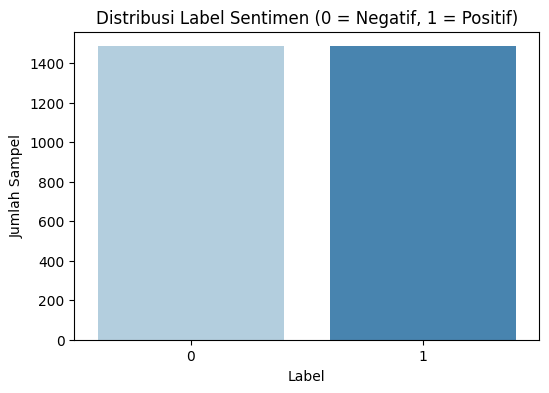

In [ ]:
# Visualisasi distribusi kelas sentimen
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df_balanced, palette='Blues')
plt.title('Distribusi Label Sentimen (0 = Negatif, 1 = Positif)')
plt.xlabel('Label')
plt.ylabel('Jumlah Sampel')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'[-+]?[0-9]+', '', text)           # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)               # Hapus tanda baca
    text = text.strip()
    return text

# Terapkan fungsi pembersihan
df['clean_review'] = df['review'].apply(clean_text)


# Inisialisasi IndoBERT Tokenizer
PRE_TRAINED_MODEL_NAME = 'indobenchmark/indobert-base-p1'
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)
MAX_LEN = 80

class ReviewDataset(Dataset):
    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]

        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

BATCH_SIZE = 16
data_loader = DataLoader(ReviewDataset(df.clean_review.to_numpy(), df.label.to_numpy(), tokenizer, MAX_LEN), batch_size=BATCH_SIZE, num_workers=2)

df.to_csv('dataset_preprocessed.csv', index=False)
print("Raw dataset saved to 'dataset_preprocessed.csv'")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Raw dataset saved to 'dataset_preprocessed.csv'
